In [1]:
from ddi_kt_2024.utils import (
    load_pkl,
    get_labels
)
test_candidates = load_pkl("cache/pkl/v2/notprocessed.candidates.test.pkl")
full_labels = get_labels(test_candidates)
with open('cache/filtered_ddi/test_filtered_index.txt', 'r') as f:
    lines = f.read().split('\n')[:-1]
    filtered_lst_index_test = [int(x.strip()) for x in lines]

2025-05-19 14:37:02,561 - DEBUG - Popen(['git', 'version'], cwd=/teamspace/studios/this_studio/DDI-Multimodals-Fusion, stdin=None, shell=False, universal_newlines=False)
2025-05-19 14:37:02,568 - DEBUG - Popen(['git', 'version'], cwd=/teamspace/studios/this_studio/DDI-Multimodals-Fusion, stdin=None, shell=False, universal_newlines=False)
2025-05-19 14:37:02,596 - DEBUG - Trying paths: ['/teamspace/studios/this_studio/.docker/config.json', '/teamspace/studios/this_studio/.dockercfg']
2025-05-19 14:37:02,597 - DEBUG - Found file at path: /teamspace/studios/this_studio/.docker/config.json
2025-05-19 14:37:02,599 - DEBUG - Couldn't find auth-related section ; attempting to interpret as auth-only file
2025-05-19 14:37:02,601 - DEBUG - Auth data for auths is absent. Client might be using a credentials store instead.
2025-05-19 14:37:02,602 - DEBUG - Auth data for aliases is absent. Client might be using a credentials store instead.


In [2]:
filtered_labels = [full_labels[i] for i in filtered_lst_index_test]

In [63]:
# pred = load_pkl('/teamspace/studios/this_studio/DDI-Multimodals-Fusion/data/sample/text_onlypred_logit_epoch25val_micro_f10.8337595907928389.pkl')
pred = load_pkl('/teamspace/studios/this_studio/DDI-Multimodals-Fusion/data/sample/bestpred_logit_epoch2val_micro_f10.8444902162718846.pkl')
# pred = load_pkl('/teamspace/studios/this_studio/DDI-Multimodals-Fusion/data/sample/pred_logit_epoch31val_micro_f10.8375893769152196.pkl')
# pred = load_pkl('/teamspace/studios/this_studio/DDI-Multimodals-Fusion/data/sample/allmodalpred_logit_epoch9val_micro_f10.8394683026584868.pkl')
# pred = load_pkl('/teamspace/studios/this_studio/DDI-Multimodals-Fusion/data/sample/highpred_logit_epoch22val_micro_f10.8443298969072164.pkl')

In [28]:
pred[10]

array([ 23.762842 ,  -5.3412414, -15.383937 , -15.716835 ,  -3.4750118],
      dtype=float32)

In [18]:
# import numpy as np
# import matplotlib.pyplot as plt
# from sklearn.metrics import roc_auc_score, precision_recall_curve, auc

# # Assuming pred shape is (3028, 5) and label is an array of len 3028


# # One-hot encode the labels
# label_onehot = np.zeros((len(label), 5))
# label_onehot[np.arange(len(label)), label] = 1

# # Calculate AUC for each class
# auc_values = []
# for i in range(5):
#     auc_values.append(roc_auc_score(label_onehot[:, i], pred_softmax[:, i]))

# # Calculate AUPR for each class
# aupr_values = []
# for i in range(5):
#     precision, recall, _ = precision_recall_curve(label_onehot[:, i], pred_softmax[:, i])
#     aupr_values.append(auc(recall, precision))

# # Create AUC and AUPR charts
# plt.figure(figsize=(10, 5))

# plt.subplot(1, 2, 1)
# plt.bar(range(5), auc_values)
# plt.xlabel('Class')
# plt.ylabel('AUC')
# plt.title('AUC Chart')

# plt.subplot(1, 2, 2)
# plt.bar(range(5), aupr_values)
# plt.xlabel('Class')
# plt.ylabel('AUPR')
# plt.title('AUPR Chart')

# plt.tight_layout()
# plt.show()

In [61]:
import numpy as np
import matplotlib.pyplot as plt
pred = pred  # your prediction array
label = filtered_labels  # your label array
def get_roc_image(pred, label, name):
    classes = ['negative', 'Advice', 'Effect', 'Mechanism', 'Other Int.']
    label_onehot = np.zeros((len(label), 5))
    label_onehot[np.arange(len(label)), label] = 1
    # Apply softmax to pred
    pred_softmax = np.exp(pred) / np.sum(np.exp(pred), axis=1, keepdims=True)
    from sklearn.metrics import roc_curve, auc
    for i in range(1,5):
        fpr, tpr, _ = roc_curve(label_onehot[:, i], pred_softmax[:, i])
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, label=f'{classes[i]} (AUC = {roc_auc:.2f})')

    plt.plot([0, 1], [0, 1], 'k--')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curve')
    plt.legend()
    plt.savefig(f'{name}_roc_curve.png', dpi=300) 
    plt.show()

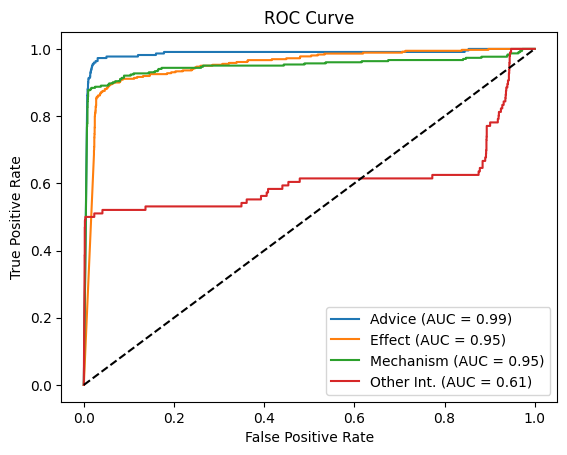

In [64]:
get_roc_image(pred,label,'best')

In [59]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, auc

# Assuming pred shape is (3028, 5) and label is an array of len 3028
pred = pred  # your prediction array
label = filtered_labels  # your label array
def get_aupr_image(pred, label, name):
    # One-hot encode the labels
    label_onehot = np.zeros((len(label), 5))
    label_onehot[np.arange(len(label)), label] = 1
    pred_softmax = np.exp(pred) / np.sum(np.exp(pred), axis=1, keepdims=True)
    classes = ['negative', 'Advice', 'Effect', 'Mechanism', 'Other Int.']
    # Plot AUPR Curve for each class
    for i in range(1,5):
        precision, recall, _ = precision_recall_curve(label_onehot[:, i], pred_softmax[:, i])
        aupr = auc(recall, precision)
        plt.plot(recall, precision, label=f'{classes[i]} (AUPR = {aupr:.2f})')

    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title('AUPR Curve')
    plt.legend(loc='lower left')
    plt.savefig(f'{name}_aupr_curve.png', dpi=300) 
    plt.show()

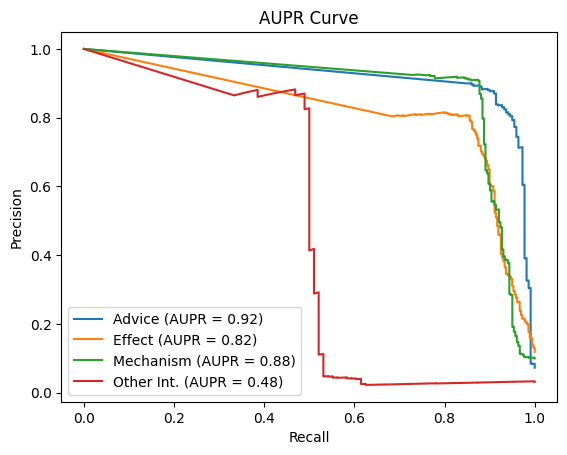

In [65]:
get_aupr_image(pred,label,'best')

In [66]:
from PIL import Image

def merge_images_into_quarters(image_paths, output_path):
    """
    Merge four images into one, dividing the resulting image into four quarters.

    Args:
        image_paths (list): List of paths to the four images to be merged.
        output_path (str): Path where the merged image will be saved.

    Returns:
        None
    """
    if len(image_paths) != 4:
        raise ValueError("Exactly four image paths are required.")

    # Open the images
    images = [Image.open(path) for path in image_paths]

    # Ensure all images are the same size for simplicity
    sizes = [img.size for img in images]
    if len(set(sizes)) != 1:
        raise ValueError("All images must be the same size.")

    # Calculate the size of the merged image
    width, height = sizes[0]
    merged_width, merged_height = width * 2, height * 2

    # Create a new image for the merged result
    merged_image = Image.new('RGB', (merged_width, merged_height))

    # Paste the images into their respective quarters
    # Top-left quarter
    merged_image.paste(images[0], (0, 0))
    # Top-right quarter
    merged_image.paste(images[1], (width, 0))
    # Bottom-left quarter
    merged_image.paste(images[2], (0, height))
    # Bottom-right quarter
    merged_image.paste(images[3], (width, height))

    # Save the merged image
    merged_image.save(output_path)

# Example usage
image_paths = ['text_only_roc_curve.png', 'text_only_aupr_curve.png', 'best_roc_curve.png', 'best_aupr_curve.png']
output_path = 'merged_image.png'
merge_images_into_quarters(image_paths, output_path)

2025-05-19 15:03:46,457 - DEBUG - STREAM b'IHDR' 16 13
2025-05-19 15:03:46,464 - DEBUG - STREAM b'tEXt' 41 58
2025-05-19 15:03:46,466 - DEBUG - STREAM b'pHYs' 111 9
2025-05-19 15:03:46,467 - DEBUG - STREAM b'IDAT' 132 65536
2025-05-19 15:03:46,472 - DEBUG - STREAM b'IHDR' 16 13
2025-05-19 15:03:46,472 - DEBUG - STREAM b'tEXt' 41 58
2025-05-19 15:03:46,473 - DEBUG - STREAM b'pHYs' 111 9
2025-05-19 15:03:46,476 - DEBUG - STREAM b'IDAT' 132 65536
2025-05-19 15:03:46,477 - DEBUG - STREAM b'IHDR' 16 13
2025-05-19 15:03:46,477 - DEBUG - STREAM b'tEXt' 41 58
2025-05-19 15:03:46,478 - DEBUG - STREAM b'pHYs' 111 9
2025-05-19 15:03:46,484 - DEBUG - STREAM b'IDAT' 132 65536
2025-05-19 15:03:46,486 - DEBUG - STREAM b'IHDR' 16 13
2025-05-19 15:03:46,486 - DEBUG - STREAM b'tEXt' 41 58
2025-05-19 15:03:46,489 - DEBUG - STREAM b'pHYs' 111 9
2025-05-19 15:03:46,490 - DEBUG - STREAM b'IDAT' 132 65536


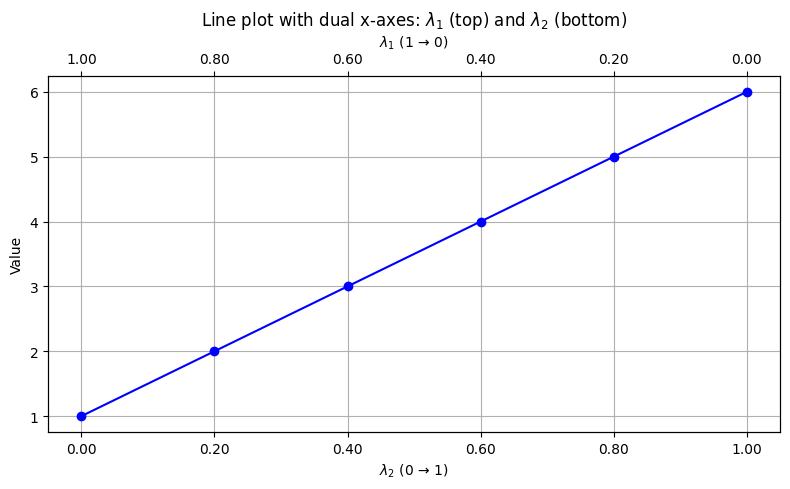

In [1]:
import matplotlib.pyplot as plt
import numpy as np

# Data
values = [1, 2, 3, 4, 5, 6]
lambda_1 = np.linspace(1, 0, len(values))  # top x-axis
lambda_2 = 1 - lambda_1                    # bottom x-axis
x = np.arange(len(values))

# Create the figure and primary axis
fig, ax1 = plt.subplots(figsize=(8, 5))

# Plot the values
ax1.plot(x, values, marker='o', color='blue')
ax1.set_ylabel('Value')
ax1.set_xlabel(r'$\lambda_2$ (0 → 1)')
ax1.set_xticks(x)
ax1.set_xticklabels([f'{l:.2f}' for l in lambda_2])

# Top axis for λ₁
ax2 = ax1.twiny()
ax2.set_xlim(ax1.get_xlim())
ax2.set_xticks(x)
ax2.set_xticklabels([f'{l:.2f}' for l in lambda_1])
ax2.set_xlabel(r'$\lambda_1$ (1 → 0)')

# Title with lambda symbols
plt.title(r'Line plot with dual x-axes: $\lambda_1$ (top) and $\lambda_2$ (bottom)')
ax1.grid(True)
plt.tight_layout()
plt.show()


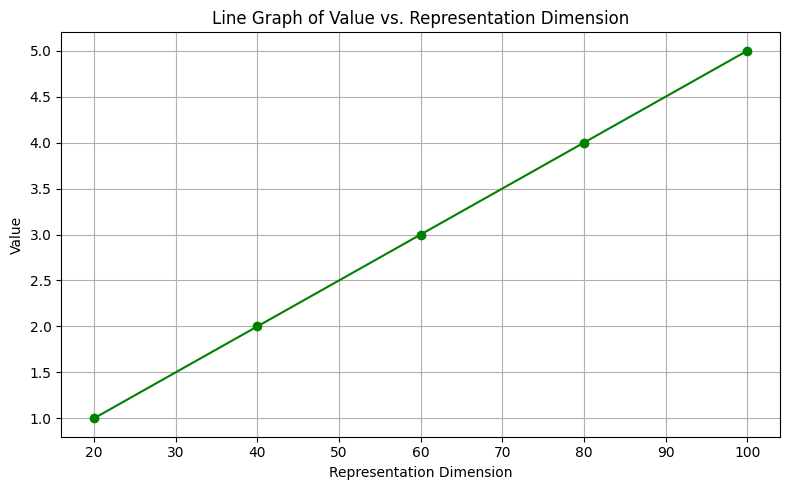

In [2]:
import matplotlib.pyplot as plt

# Data
represent_dim = [20, 40, 60, 80, 100]
values = [1, 2, 3, 4, 5]

# Plot
plt.figure(figsize=(8, 5))
plt.plot(represent_dim, values, marker='o', color='green')

# Labels and title
plt.xlabel('Representation Dimension')
plt.ylabel('Value')
plt.title('Line Graph of Value vs. Representation Dimension')
plt.grid(True)

# Show
plt.tight_layout()
plt.show()
